# Notebook 10 — Figures 15 & 16: Mean-Variance Efficient Frontiers

**Data needed:**
- `data/grid/cluster_month_panel_K_50_lambda_1000000.csv`
- `data/factor_returns.csv`
- `data/mebm_25.csv`          — Fama-French 25 ME-BM portfolios
- `data/benchmark_sorts.csv`  — Uni-Sort 150, Bi-Sort 285, Ind49

**`mebm_25.csv`** format: `date, P11, P12, ..., P55` (25 columns, Ken French website)  
**`benchmark_sorts.csv`** format: `date, US_1, US_2, ..., BS_1, ..., IND_1, ...`

**Output:**
- Figure 15: Scatter plots in (mean, std) and (CAPM alpha, beta) space for two subsamples
- Figure 16: MVE frontier comparison full sample 1977-2020

In [1]:
import os, sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)

from utils.data_utils import (load_cluster_panel, load_cluster_ranking,
                               pivot_and_rank, save_figure, DATA_DIR)

mpl.rcParams.update({
    'font.family':       'serif',
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.titlesize':    13,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Paths ──────────────────────────────────────────────────────────
BASE     = "/ssd1/songjiangliu/shared/asset_clustering"
DATA_PATH = "/ssd1/songjiangliu/shared/asset_clustering/Data"
OUT_DIR  = os.path.join(REPO_ROOT, "output", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

print("Imports done.")
print(f"Data dir  : {DATA_PATH}")
print(f"Output dir: {OUT_DIR}")

Imports done.
Data dir  : /ssd1/songjiangliu/shared/asset_clustering/Data
Output dir: /ssd1/songjiangliu/shared/asset_clustering/Replication Package/output/figures


In [2]:
# ── Helper functions (from Figure_7__3_.ipynb reference) ──────────

def _dedup(df):
    """Drop duplicate DatetimeIndex rows, keeping first."""
    return df[~df.index.duplicated(keep='first')]

def read_french_csv(filepath, n_port_cols=None, missing_vals=None):
    """
    Robustly read a Ken French data library CSV.
    Auto-detects where the yyyymm data rows start, reads VW section only,
    converts percent to decimal, returns DataFrame with DatetimeIndex.
    """
    if missing_vals is None:
        missing_vals = [-99.99, -999.0, -9999.0]

    with open(filepath, 'r') as f:
        raw_lines = f.readlines()

    header_idx = data_idx = None
    for i, line in enumerate(raw_lines):
        first_tok = line.strip().lstrip(',').split(',')[0].strip()
        if re.match(r'^\d{6}$', first_tok):
            data_idx   = i
            header_idx = i - 1
            break

    if data_idx is None:
        raise ValueError(f'Cannot find data start in: {filepath}')

    df = pd.read_csv(filepath, skiprows=header_idx, index_col=0,
                     on_bad_lines='skip')
    df = df[df.index.astype(str).str.match(r'^\d{6}$')].copy()
    df = df.apply(pd.to_numeric, errors='coerce')

    for mv in missing_vals:
        df.replace(mv, np.nan, inplace=True)

    if n_port_cols is not None:
        df = df.iloc[:, :n_port_cols]

    df = df / 100.0
    df.index = pd.to_datetime(df.index.astype(str), format='%Y%m')
    df.index.name = 'year_month'
    return df


def make_excess(raw_df, rf_series, min_obs=60):
    """Subtract RF from raw returns; drop sparse columns."""
    if raw_df is None:
        aligned = _dedup(raw_df).reindex(rf_series.index)
        excess  = aligned.subtract(rf_series, axis=0)
        excess  = excess.loc[:, excess.notna().sum() >= min_obs]
        return excess.dropna(how='all')


def capm_stats(returns_df, mkt_series):
    """Per-portfolio CAPM OLS with HAC SEs. Returns % per month."""
    R = _dedup(returns_df)
    M = _dedup(mkt_series.dropna().to_frame()).iloc[:, 0]
    common = R.index.intersection(M.index)
    R, M = R.loc[common], M.loc[common]
    rows = []
    for col in R.columns:
        y = R[col].dropna()
        x = M.reindex(y.index).dropna()
        y = y.reindex(x.index)
        if len(y) < 24:
            continue
        res = sm.OLS(y, sm.add_constant(x)).fit(
            cov_type='HAC', cov_kwds={'maxlags': 3})
        rows.append({'portfolio':  col,
                     'mean_ret':   y.mean()      * 100,
                     'std_ret':    y.std(ddof=1) * 100,
                     'alpha_capm': res.params.iloc[0] * 100,
                     'beta_capm':  res.params.iloc[1]})
    return pd.DataFrame(rows).set_index('portfolio')


def mve_frontier(returns_df, n_points=500, shrink=1e-3):
    """
    Analytical MVE frontier via two-fund separation theorem.
    var(rp) = (C*rp^2 - 2A*rp + B) / D
    Returns (std_arr, mean_arr, (tan_std, tan_mean)) in % per month.
    """
    R    = returns_df.dropna(axis=1, how='any').dropna(axis=0, how='any').values
    T, N = R.shape
    mu   = R.mean(axis=0)
    Sig  = np.cov(R, rowvar=False) + shrink * np.eye(N)
    iS   = np.linalg.pinv(Sig)
    ones = np.ones(N)

    A = float(ones @ iS @ mu)
    B = float(mu   @ iS @ mu)
    C = float(ones @ iS @ ones)
    D = B * C - A**2

    w_tan    = iS @ mu
    scale    = float(ones @ w_tan)
    tan_mean = float(w_tan @ mu) / scale
    tan_var  = float(w_tan @ Sig @ w_tan) / scale**2
    tan_std  = np.sqrt(max(tan_var, 0))

    rp_gmv = A / C
    rp_max = max(mu.max(), tan_mean) * 1.5
    rp_max = max(rp_max, rp_gmv * 3)
    rps    = np.linspace(rp_gmv, rp_max, n_points)

    var_arr  = (C * rps**2 - 2 * A * rps + B) / D
    std_arr  = np.sqrt(np.maximum(var_arr, 0)) * 100
    mean_arr = rps * 100

    return std_arr, mean_arr, (tan_std * 100, tan_mean * 100)


SCALE_ANCHORS = {
    'Cluster (Ours)', 'ME-BM 5x5', 'ME-BM 5x5', 'Uni-Sort',
    'Bi-Sort', 'Ind49', 'FF5', 'FF3', 'FFC', 'Q5', 'CAPM',
}

def compute_axis_limits(frontiers_dict, anchors, x_pad=1.15, y_pad=1.20):
    """Axis limits from 98th-pct of anchor frontier curves."""    
    all_stds, all_means = [], []
    candidates = {k: v for k, v in frontiers_dict.items() if k in anchors}
    if not candidates:
        candidates = frontiers_dict
    for name, (stds, means, tan) in candidates.items():
        all_stds.extend( [v for v in stds.tolist() + [tan[0]] if np.isfinite(v) and v >= 0])
        all_means.extend([v for v in means.tolist()+ [tan[1]] if np.isfinite(v)])
    if not all_stds or not all_means:
        return 15.0, -0.1, 2.0
    x_max = float(np.percentile(all_stds,  98)) * x_pad
    y_max = float(np.percentile(all_means, 98)) * y_pad
    y_min = float(min(0.0, float(np.min(all_means)))) - 0.05
    if not np.isfinite(x_max) or x_max <= 0: x_max = 15.0
    if not np.isfinite(y_max):               y_max =  2.0
    if not np.isfinite(y_min):               y_min = -0.1
    return x_max, y_min, y_max


print("Helper functions defined.")

Helper functions defined.


In [3]:
# ── Load cluster portfolios ────────────────────────────────────────
ranking        = load_cluster_ranking()
df_cl          = load_cluster_panel(K=50, lam=1_000_000)
cr_r, rank_map = pivot_and_rank(df_cl, lam=1_000_000, ranking_df=ranking)

# Also build the rank-by-mean-return version used in the reference
# (pivot_and_rank uses official Cluster_Ranking.csv)
cluster_info = pd.read_csv(
    os.path.join(BASE, "Results", "cluster_month_panels_K_50",
                 "cluster_month_panel_K_50_lambda_1000000.csv")
)
Cluster_ret = cluster_info[['year_month','cluster','r_t1_wmean']].dropna()
Cluster_ret['year_month'] = pd.to_datetime(Cluster_ret['year_month'])

cluster_mean = (
    Cluster_ret.groupby('cluster')['r_t1_wmean'].mean()
    .sort_values().reset_index()
)
cluster_mean['portfolio'] = (
    cluster_mean['r_t1_wmean'].rank(method='first', ascending=True).astype(int)
)
Cluster_ret = Cluster_ret.merge(cluster_mean[['cluster','portfolio']], on='cluster')

pivot_ret = (
    Cluster_ret.pivot_table(index='year_month', columns='portfolio',
                             values='r_t1_wmean').reset_index()
)
pivot_ret.dropna(inplace=True)
pivot_ret['year']  = pivot_ret['year_month'].dt.year
pivot_ret['month'] = pivot_ret['year_month'].dt.month
port_list = [c for c in pivot_ret.columns if isinstance(c, int)]

print(f"Cluster portfolios : {len(port_list)}")
print(f"Date range         : {pivot_ret['year_month'].min().date()} - {pivot_ret['year_month'].max().date()}")

Cluster portfolios : 50
Date range         : 1977-01-01 - 2019-12-01


In [4]:
# ── Load factor data ───────────────────────────────────────────────
JFE = pd.read_csv(os.path.join(DATA_PATH, 'All_factors_JFE.csv'))
if 'PS_VWF' in JFE.columns:
    JFE['PS_VWF'] = JFE['PS_VWF'] * 100
drop_cols = ['cap_risk','INDPRO','PCE','z_longs','z_shorts',
             'z_longs_diff','z_shorts_diff','ZLp','ZSp']
JFE.drop(columns=[c for c in drop_cols if c in JFE.columns], inplace=True)
# Convert ALL columns including RF to decimal
factor_cols_jfe = [c for c in JFE.columns if c not in ['year','month']]
JFE[factor_cols_jfe] = JFE[factor_cols_jfe] / 100.0
print(f"JFE factors: {JFE.shape}  cols: {list(JFE.columns[:8])}...")

IPCA = pd.read_csv(os.path.join(DATA_PATH, 'IPCA_factors.csv'))
IPCA.drop(columns=[c for c in ['Unnamed: 0'] if c in IPCA.columns], inplace=True)
IPCA.rename(columns={'1':'IPCA1','2':'IPCA2','3':'IPCA3','4':'IPCA4','5':'IPCA5'},
            inplace=True)
IPCA['year']  = IPCA['date'].astype(str).str[:4].astype(int)
IPCA['month'] = IPCA['date'].astype(str).str[4:6].astype(int)
IPCA.drop(columns=['date'], inplace=True)
print(f"IPCA factors: {IPCA.shape}")

LP = pd.read_csv(os.path.join(DATA_PATH, 'RP-PCA Factors 2.csv'))
def _parse_lp_date(s):
    m, y = s.split('-')
    y = int(y)
    y = 1900 + y if y >= 63 else 2000 + y
    return pd.to_datetime(f'{m} {y}', format='%b %Y')
LP['year_month'] = LP['date'].apply(_parse_lp_date)
LP['year']  = LP['year_month'].dt.year
LP['month'] = LP['year_month'].dt.month
LP.drop(columns=['date','year_month'], inplace=True)
lp_cols = [c for c in LP.columns if c not in ['year','month']]
LP[lp_cols] = LP[lp_cols] / 100.0
# Rename non-PCA cols to RPPCA_1..5
rp_other = [c for c in lp_cols if not c.startswith('PCA_')]
LP.rename(columns={c: f'RPPCA_{i+1}' for i, c in enumerate(rp_other)}, inplace=True)
print(f"RP-PCA factors: {LP.shape}  RPPCA cols: {[c for c in LP.columns if c.startswith('RPPCA_')]}")

# Merge all factors and cluster returns
factors_all = JFE.merge(IPCA, on=['year','month'], how='left')
factors_all = factors_all.merge(LP, on=['year','month'], how='left')

# Deduplicate before set_index
dupes = factors_all.duplicated(subset=['year','month'])
if dupes.any():
    print(f"WARNING: {dupes.sum()} duplicate (year,month) rows — keeping first")
    factors_all = factors_all.drop_duplicates(subset=['year','month'], keep='first')

final_data = pivot_ret.merge(factors_all, on=['year','month'], how='inner')
final_data = final_data.set_index('year_month').sort_index()
final_data = _dedup(final_data)

rf_decimal = final_data['RF'].copy()
mkt        = final_data['MKT'].copy()

print(f"\nfinal_data shape  : {final_data.shape}")
print(f"RF  mean={rf_decimal.mean():.5f}  min={rf_decimal.min():.5f}  max={rf_decimal.max():.5f}")
print(f"MKT mean={mkt.mean():.4f}  std={mkt.std():.4f}")
print(f"Date range: {final_data.index.min().date()} - {final_data.index.max().date()}")

JFE factors: (696, 22)  cols: ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'year', 'month']...
IPCA factors: (527, 7)
RP-PCA factors: (650, 12)  RPPCA cols: ['RPPCA_1', 'RPPCA_2', 'RPPCA_3', 'RPPCA_4', 'RPPCA_5']

final_data shape  : (510, 87)
RF  mean=0.00368  min=0.00000  max=0.01350
MKT mean=0.0063  std=0.0439
Date range: 1977-01-01 - 2019-12-01


In [5]:
# ── Load Ken French test asset sets ───────────────────────────────
MEBM_COLS = [
    'SMALL_LoBM','ME1_BM2','ME1_BM3','ME1_BM4','SMALL_HiBM',
    'ME2_BM1',   'ME2_BM2','ME2_BM3','ME2_BM4','ME2_BM5',
    'ME3_BM1',   'ME3_BM2','ME3_BM3','ME3_BM4','ME3_BM5',
    'ME4_BM1',   'ME4_BM2','ME4_BM3','ME4_BM4','ME4_BM5',
    'BIG_LoBM',  'ME5_BM2','ME5_BM3','ME5_BM4','BIG_HiBM',
]

# ME-BM 5x5
mebm_path = os.path.join(DATA_PATH, '25_Portfolios_5x5.csv')
if os.path.exists(mebm_path):
    mebm_raw = read_french_csv(mebm_path, n_port_cols=25)
    mebm_raw.columns = MEBM_COLS
    print(f"ME-BM 5x5   : {mebm_raw.shape}")
else:
    print(f"MISSING: {mebm_path}"); mebm_raw = None

# Ind49
ind49_path = os.path.join(DATA_PATH, '49_Industry_Portfolios.csv')
if os.path.exists(ind49_path):
    ind49_raw = read_french_csv(ind49_path, n_port_cols=49)
    print(f"Ind49       : {ind49_raw.shape}")
else:
    print(f"MISSING: {ind49_path}"); ind49_raw = None

# Uni-Sort (15 characteristics x 10 deciles)
UNISORT_SPECS = [
    # Only files confirmed present in Data folder
    ('Portfolios_Formed_on_BE-ME.csv', 'BM',  10),
    ('Portfolios_Formed_on_ME.csv',    'SIZE',10),
    ('Portfolios_Formed_on_OP.csv',    'OP',  10),
    ('Portfolios_Formed_on_INV.csv',   'INV', 10),
    ('Portfolios_Formed_on_BETA.csv',  'BETA',10),
    ('Portfolios_Formed_on_E-P.csv',   'EP',  10),
    ('Portfolios_Formed_on_CF-P.csv',  'CFP', 10),
    ('Portfolios_Formed_on_D-P.csv',   'DP',  10),
    ('Portfolios_Formed_on_NI.csv',    'NSI', 10),
    ('Portfolios_Formed_on_AC.csv',    'AC',  10),
    ('Portfolios_Formed_on_VAR.csv',   'VAR', 10),
    ('25_Portfolios_5x5.csv',          'MEBM',10),
    # Note: MOM, LT_Rev, ST_Rev files not in Data folder — omitted
]
uni_parts = []
for fname, prefix, n_cols in UNISORT_SPECS:
    p = os.path.join(DATA_PATH, fname)
    if not os.path.exists(p): continue
    try:
        raw = read_french_csv(p, n_port_cols=n_cols)
        raw = raw[~raw.index.duplicated(keep='first')]
        raw.columns = [f'{prefix}_D{j+1}' for j in range(raw.shape[1])]
        uni_parts.append(raw)
    except Exception as e:
        print(f"  {prefix}: LOAD ERROR - {e}")
uni_parts   = [p[~p.index.duplicated(keep='first')] for p in uni_parts]
unisort_raw = pd.concat(uni_parts, axis=1) if uni_parts else None
print(f"Uni-Sort    : {unisort_raw.shape[1] if unisort_raw is not None else 0} portfolios")

# Bi-Sort (bivariate sorts)
BISORT_SPECS = [
    ('25_Portfolios_5x5.csv',           'ME_BM',   25),
    ('25_Portfolios_ME_OP_5x5.csv',     'ME_OP',   25),
    ('25_Portfolios_ME_INV_5x5.csv',    'ME_INV',  25),
    ('25_Portfolios_ME_Prior_12_2.csv', 'ME_MOM',  25),
    ('25_Portfolios_ME_BETA_5x5.csv',   'ME_BETA', 25),
    ('25_Portfolios_ME_Prior_1_0.csv',  'ME_STR',  25),
    ('25_Portfolios_ME_Prior_60_13.csv','ME_LTR',  25),
    ('25_Portfolios_ME_VAR_5x5.csv',    'ME_VAR',  25),
    ('25_Portfolios_ME_RESVAR_5x5.csv', 'ME_RVAR', 25),
    ('25_Portfolios_ME_AC_5x5.csv',     'ME_AC',   25),
    # Note: 35_Portfolios_ME_NI_5x7.csv not available — omitted
]
bi_parts = []
for fname, prefix, n_cols in BISORT_SPECS:
    p = os.path.join(DATA_PATH, fname)
    if not os.path.exists(p): continue
    try:
        raw = read_french_csv(p, n_port_cols=n_cols)
        raw = raw[~raw.index.duplicated(keep='first')]
        raw.columns = [f'{prefix}_{j+1}' for j in range(raw.shape[1])]
        bi_parts.append(raw)
    except Exception as e:
        print(f"  {prefix}: LOAD ERROR - {e}")
bi_parts   = [p[~p.index.duplicated(keep='first')] for p in bi_parts]
bisort_raw = pd.concat(bi_parts, axis=1) if bi_parts else None
print(f"Bi-Sort     : {bisort_raw.shape[1] if bisort_raw is not None else 0} portfolios")

ME-BM 5x5   : (8680, 25)
Ind49       : (4784, 49)
Uni-Sort    : 120 portfolios
Bi-Sort     : 250 portfolios


In [10]:
# ── Build excess-return matrices for all test assets ───────────────
idx = final_data.index

# Cluster returns: r_t1_wmean is already excess; subtract RF to be consistent
# Cluster returns — already excess, subtract RF to be consistent
R_cluster = _dedup(final_data[port_list]).subtract(rf_decimal, axis=0)

def make_excess_safe(raw_df, rf_series, min_obs=60):
    if raw_df is None:
        return None

    # ── Fix duplicate COLUMNS first ───────────────────────────────
    if raw_df.columns.duplicated().any():
        # Make column names unique by appending _1, _2, ...
        cols = pd.Series(raw_df.columns.astype(str))
        counts = cols.groupby(cols).cumcount()
        raw_df = raw_df.copy()
        raw_df.columns = [
            f"{c}_{n}" if n > 0 else c
            for c, n in zip(cols, counts)
        ]

    # ── Align on Period(M) to avoid day-offset mismatches ─────────
    raw_p = raw_df.copy()
    raw_p.index = raw_p.index.to_period('M')

    rf_p = rf_series.copy()
    rf_p.index = rf_p.index.to_period('M')

    # Deduplicate index rows
    raw_p = raw_p[~raw_p.index.duplicated(keep='first')]
    rf_p  = rf_p[~rf_p.index.duplicated(keep='first')]

    common = raw_p.index.intersection(rf_p.index)
    if len(common) == 0:
        print("  WARNING: no common dates after period alignment")
        return None

    excess = raw_p.loc[common].subtract(rf_p.loc[common], axis=0)
    excess = excess.loc[:, excess.notna().sum() >= min_obs]

    if excess.empty:
        return None

    excess.index = excess.index.to_timestamp()
    return excess.dropna(how='all')

R_mebm    = make_excess_safe(mebm_raw,    rf_decimal)
R_ind49   = make_excess_safe(ind49_raw,   rf_decimal)
R_unisort = make_excess_safe(unisort_raw, rf_decimal)
R_bisort  = make_excess_safe(bisort_raw,  rf_decimal)

for name, R in [('Cluster (Ours)', R_cluster),
                ('ME-BM 5x5',      R_mebm),
                ('Ind49',          R_ind49),
                ('Uni-Sort',       R_unisort),
                ('Bi-Sort',        R_bisort)]:
    if R is not None:
        obs = R.dropna(how='all').shape[0]
        mu_rng = f"[{R.mean().min()*100:+.2f}%, {R.mean().max()*100:+.2f}%]"
        print(f"{name:<20}: {R.shape[1]:3d} ports  {obs:4d} months  mean {mu_rng}")
    else:
        print(f"{name:<20}: NOT LOADED")

# CAPM stats for Figure 15
stats_cluster = capm_stats(R_cluster, mkt)
stats_mebm    = capm_stats(R_mebm, mkt) if R_mebm is not None else None

Cluster (Ours)      :  50 ports   510 months  mean [-2.31%, +1.20%]
ME-BM 5x5           :  25 ports   510 months  mean [+0.29%, +1.05%]
Ind49               :  49 ports   510 months  mean [+0.23%, +1.26%]
Uni-Sort            : 119 ports   510 months  mean [+0.29%, +1.05%]
Bi-Sort             : 250 ports   510 months  mean [-0.21%, +1.33%]


In [11]:
# Normalise all return matrices to Period-free DatetimeIndex (start of month)
def _to_timestamp(df):
    if df is None: return None
    if hasattr(df.index, 'to_timestamp'):
        df = df.copy()
        df.index = df.index.to_timestamp()
    return df

R_mebm    = _to_timestamp(R_mebm)
R_ind49   = _to_timestamp(R_ind49)
R_unisort = _to_timestamp(R_unisort)
R_bisort  = _to_timestamp(R_bisort)

# Also normalise final_data and R_cluster to start-of-month
final_data.index = final_data.index.to_period('M').to_timestamp()
rf_decimal.index = rf_decimal.index.to_period('M').to_timestamp()
mkt.index        = mkt.index.to_period('M').to_timestamp()
R_cluster.index  = R_cluster.index.to_period('M').to_timestamp()

In [12]:
# ── Factor sets ────────────────────────────────────────────────────
factor_sets = {
    'CAPM':   ['MKT'],
    'FF3':    ['MKT','SMB','HML'],
    'FF5':    ['MKT','SMB','HML','RMW','CMA'],
    'FFC':    ['MKT','SMB','HML','Mom'],
    'Q5':     ['MKT','R_ME','R_IA','R_ROE','R_EG'],
    'DHS':    ['MKT','PEAD','FIN'],
    'RPPCA5': ['RPPCA_1','RPPCA_2','RPPCA_3','RPPCA_4','RPPCA_5'],
    'PCA5':   ['PCA_1',  'PCA_2',  'PCA_3',  'PCA_4',  'PCA_5'],
}

print("Factor column availability:")
for name, cols in factor_sets.items():
    missing = [c for c in cols if c not in final_data.columns]
    status  = "OK" if not missing else f"MISSING: {missing}"
    print(f"  {name:<8}: {status}")

Factor column availability:
  CAPM    : OK
  FF3     : OK
  FF5     : OK
  FFC     : OK
  Q5      : OK
  DHS     : OK
  RPPCA5  : OK
  PCA5    : OK


In [13]:
# ── Compute all MVE frontiers ──────────────────────────────────────
print("Computing frontiers (analytical closed-form)...")
frontiers = {}

test_asset_sets = [
    ('Cluster (Ours)', R_cluster),
    ('ME-BM 5x5',      R_mebm),
    ('Uni-Sort',       R_unisort),
    ('Bi-Sort',        R_bisort),
    ('Ind49',          R_ind49),
]

for name, R in test_asset_sets:
    if R is not None and R.dropna(how='all').shape[0] >= 60:
        try:
            frontiers[name] = mve_frontier(_dedup(R))
            tan = frontiers[name][2]
            sr  = tan[1]/tan[0]*np.sqrt(12) if tan[0] > 0 else np.nan
            print(f"  {name:<20}: SR={sr:5.2f}  tan_mean={tan[1]:+.3f}%")
        except Exception as e:
            print(f"  {name:<20}: FAILED - {e}")
    else:
        print(f"  {name:<20}: SKIPPED")

for name, cols in factor_sets.items():
    avail = [c for c in cols if c in final_data.columns]
    if len(avail) < len(cols):
        print(f"  {name:<8}: SKIPPED - missing {set(cols)-set(avail)}")
        continue
    try:
        R_f = _dedup(final_data[avail]).dropna()
        frontiers[name] = mve_frontier(R_f)
        tan = frontiers[name][2]
        sr  = tan[1]/tan[0]*np.sqrt(12) if tan[0] > 0 else np.nan
        print(f"  {name:<8}: SR={sr:5.2f}  tan_mean={tan[1]:+.3f}%")
    except Exception as e:
        print(f"  {name:<8}: FAILED - {e}")

print(f"\nTotal frontiers: {len(frontiers)}")

Computing frontiers (analytical closed-form)...
  Cluster (Ours)      : SR= 2.20  tan_mean=+9.390%
  ME-BM 5x5           : SR= 0.94  tan_mean=+1.590%
  Uni-Sort            : SR= 1.32  tan_mean=+1.888%
  Bi-Sort             : SR= 2.04  tan_mean=+3.671%
  Ind49               : SR= 1.02  tan_mean=+1.582%
  CAPM    : SR= 0.40  tan_mean=+0.630%
  FF3     : SR= 0.48  tan_mean=+0.412%
  FF5     : SR= 0.65  tan_mean=+0.365%
  FFC     : SR= 0.67  tan_mean=+0.479%
  Q5      : SR= 1.08  tan_mean=+0.583%
  DHS     : SR= 0.92  tan_mean=+0.613%
  RPPCA5  : SR= 1.52  tan_mean=+1.488%
  PCA5    : SR= 1.00  tan_mean=+1.316%

Total frontiers: 13


In [14]:
# ── Sharpe ratio summary table ─────────────────────────────────────
rows = []
for name, (stds, means, tan) in frontiers.items():
    tan_std, tan_mean = tan
    sr = tan_mean / tan_std * np.sqrt(12) if tan_std > 0 else np.nan
    rows.append({'Model / Test Asset':     name,
                 'Tangency Mean (% / mo)': round(tan_mean, 4),
                 'Tangency Std (% / mo)':  round(tan_std,  4),
                 'Sharpe (ann.)':          round(sr, 3)})

summary_df = (pd.DataFrame(rows)
              .sort_values('Sharpe (ann.)', ascending=False)
              .reset_index(drop=True))
print(summary_df.to_string(index=False))

Model / Test Asset  Tangency Mean (% / mo)  Tangency Std (% / mo)  Sharpe (ann.)
    Cluster (Ours)                  9.3897                14.8055          2.197
           Bi-Sort                  3.6707                 6.2404          2.038
            RPPCA5                  1.4882                 3.3927          1.519
          Uni-Sort                  1.8883                 4.9385          1.325
                Q5                  0.5833                 1.8745          1.078
             Ind49                  1.5822                 5.3591          1.023
              PCA5                  1.3163                 4.5507          1.002
         ME-BM 5x5                  1.5900                 5.8300          0.945
               DHS                  0.6129                 2.2973          0.924
               FFC                  0.4791                 2.4831          0.668
               FF5                  0.3648                 1.9536          0.647
               FF3          

In [15]:
# ── Style map ──────────────────────────────────────────────────────
style_map = {
    'Cluster (Ours)': dict(color='#d62728', lw=2.8, ls='-',  zorder=10),
    'ME-BM 5x5':      dict(color='#9467bd', lw=1.8, ls='--', zorder=6),
    'Uni-Sort':       dict(color='#ff7f0e', lw=1.6, ls='--', zorder=5),
    'Bi-Sort':        dict(color='#ff7f0e', lw=1.6, ls=':',  zorder=5),
    'Ind49':          dict(color='#2ca02c', lw=1.6, ls='--', zorder=5),
    'CAPM':           dict(color='black',   lw=1.2, ls='-',  zorder=4),
    'FF3':            dict(color='black',   lw=1.2, ls='--', zorder=4),
    'FFC':            dict(color='black',   lw=1.2, ls=':',  zorder=4),
    'FF5':            dict(color='black',   lw=1.8, ls='-.', zorder=4),
    'Q5':             dict(color='#555555', lw=1.2, ls='--', zorder=3),
    'DHS':            dict(color='#555555', lw=1.2, ls=':',  zorder=3),
    'RPPCA5':         dict(color='#1f77b4', lw=1.5, ls=':',  zorder=2),
    'PCA5':           dict(color='#1f77b4', lw=1.2, ls='-',  zorder=2),
}
print("Style map defined.")

Style map defined.


Axis limits -> x: [0, 21.06]  y: [-0.050, 13.600]


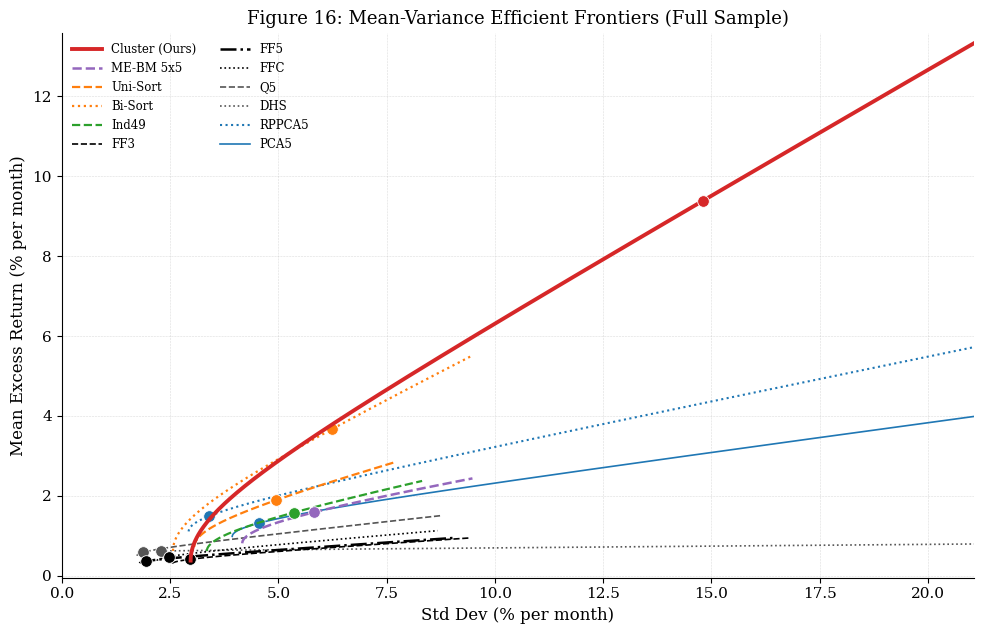

Figure 16 saved.


In [16]:
# ── Figure 16: Full-sample MVE frontier ───────────────────────────
x_max, y_min, y_max = compute_axis_limits(frontiers, SCALE_ANCHORS)
print(f"Axis limits -> x: [0, {x_max:.2f}]  y: [{y_min:.3f}, {y_max:.3f}]")

fig, ax = plt.subplots(figsize=(10, 6.5))

for name, (stds, means, tan) in frontiers.items():
    sty  = style_map.get(name, dict(color='gray', lw=1.0, ls='-', zorder=1))
    mask = (np.isfinite(stds) & np.isfinite(means)
            & (stds <= x_max * 1.05) & (means >= y_min))
    if mask.sum() < 2:
        continue
    plot_kw = {k: v for k, v in sty.items() if k != 'zorder'}
    ax.plot(stds[mask], means[mask], label=name,
            zorder=sty.get('zorder', 1), **plot_kw)
    if (np.isfinite(tan[0]) and np.isfinite(tan[1])
            and tan[0] <= x_max * 1.1
            and y_min <= tan[1] <= y_max * 1.5):
        ax.scatter(tan[0], tan[1], color=sty['color'], s=70,
                   edgecolors='white', linewidths=0.6,
                   zorder=sty.get('zorder', 1) + 1)

ax.set_xlim(0, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Std Dev (% per month)')
ax.set_ylabel('Mean Excess Return (% per month)')
ax.set_title('Figure 16: Mean-Variance Efficient Frontiers (Full Sample)')
ax.legend(frameon=False, loc='upper left', ncol=2, fontsize=8.5, handlelength=2.5)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.45)
plt.tight_layout()
for ext in ['pdf','png']:
    plt.savefig(os.path.join(OUT_DIR, f'Figure16_MVE_Frontier.{ext}'),
                dpi=300, bbox_inches='tight')
plt.show()
print("Figure 16 saved.")

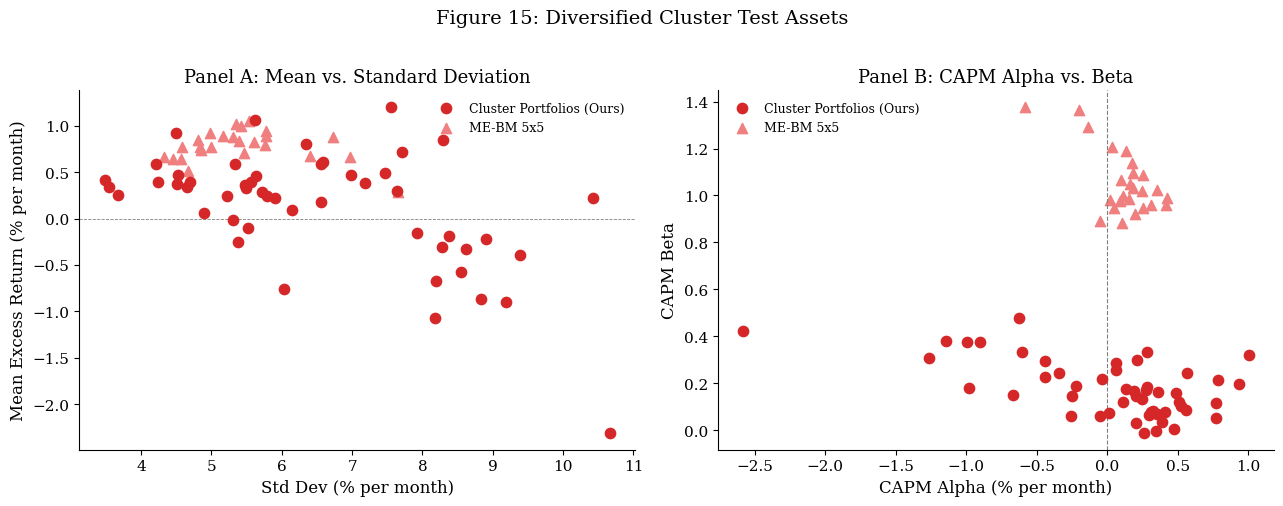

Figure 15 saved.


In [17]:
# ── Figure 15: Cluster test assets — Mean vs Std + Alpha vs Beta ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(stats_cluster['std_ret'], stats_cluster['mean_ret'],
           color='#d62728', marker='o', s=55, zorder=3,
           label='Cluster Portfolios (Ours)')
if stats_mebm is not None:
    ax.scatter(stats_mebm['std_ret'], stats_mebm['mean_ret'],
               color='lightcoral', marker='^', s=55, zorder=2,
               label='ME-BM 5x5')
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.set_xlabel('Std Dev (% per month)')
ax.set_ylabel('Mean Excess Return (% per month)')
ax.set_title('Panel A: Mean vs. Standard Deviation')
ax.legend(frameon=False)

ax = axes[1]
ax.scatter(stats_cluster['alpha_capm'], stats_cluster['beta_capm'],
           color='#d62728', marker='o', s=55, zorder=3,
           label='Cluster Portfolios (Ours)')
if stats_mebm is not None:
    ax.scatter(stats_mebm['alpha_capm'], stats_mebm['beta_capm'],
               color='lightcoral', marker='^', s=55, zorder=2,
               label='ME-BM 5x5')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('CAPM Alpha (% per month)')
ax.set_ylabel('CAPM Beta')
ax.set_title('Panel B: CAPM Alpha vs. Beta')
ax.legend(frameon=False)

plt.suptitle('Figure 15: Diversified Cluster Test Assets', fontsize=14, y=1.01)
plt.tight_layout()
for ext in ['pdf','png']:
    plt.savefig(os.path.join(OUT_DIR, f'Figure15_Cluster_Test_Assets.{ext}'),
                dpi=300, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

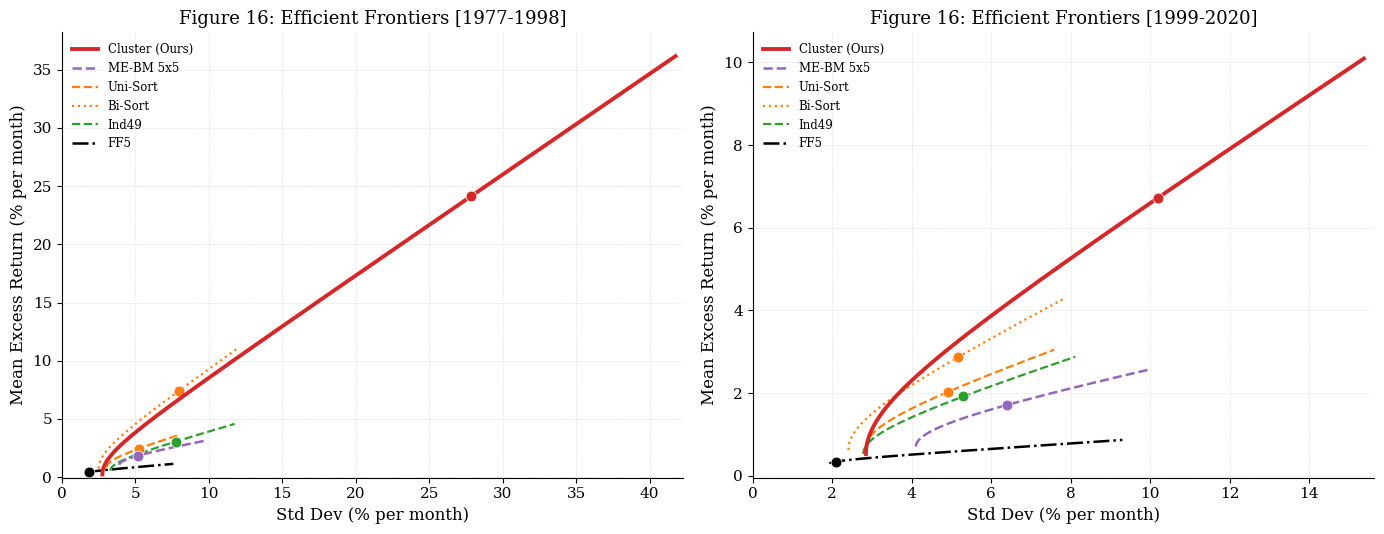

Figure 16 (subsamples) saved.


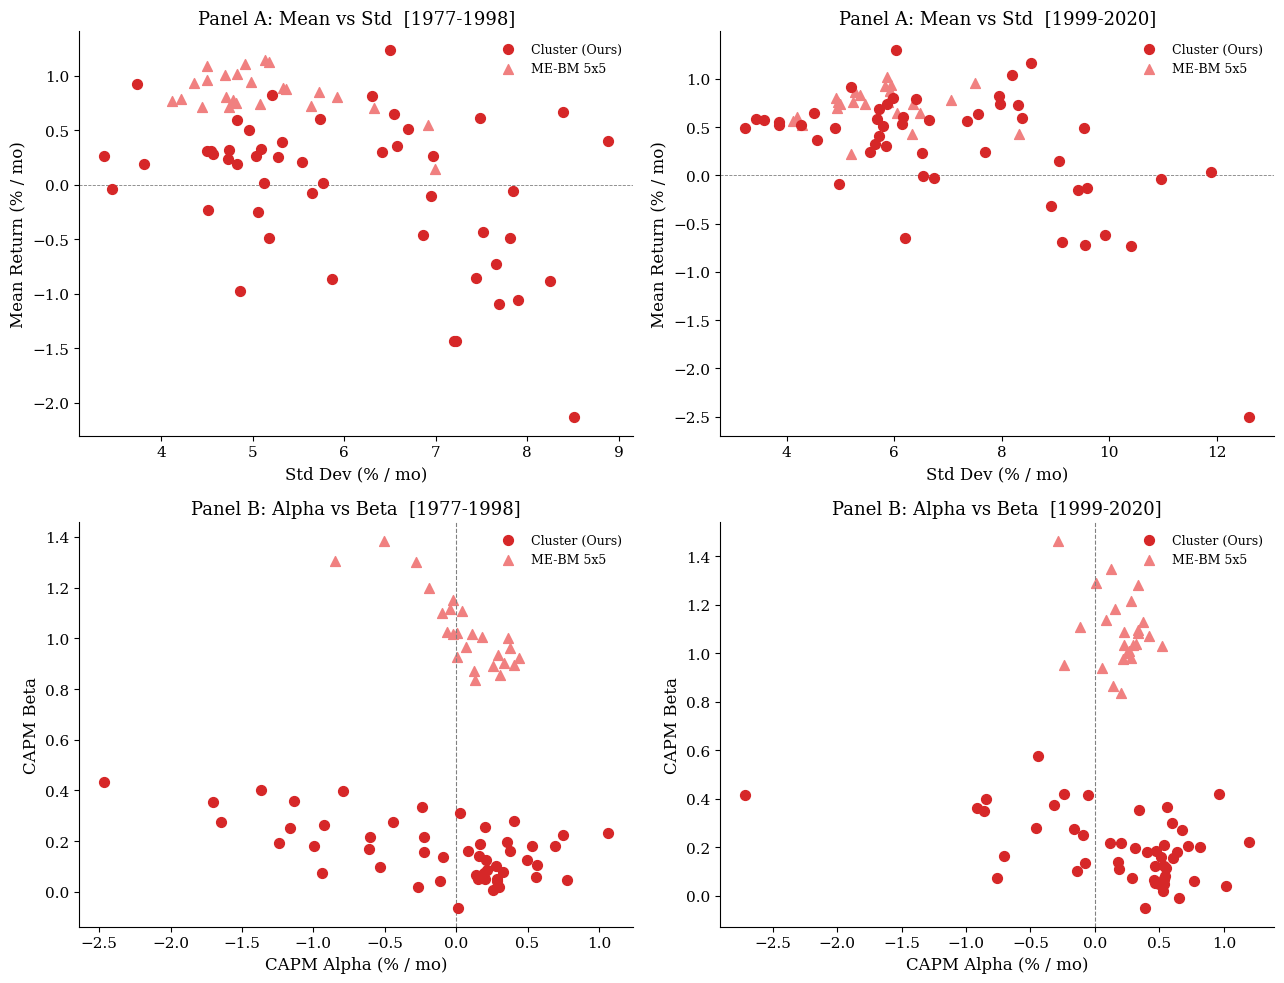

Figures 15 and 16 (subsamples) saved.


In [18]:
# ── Subsample plots (1977-1998 and 1999-2020) ─────────────────────
subsamples = {
    '1977-1998': ('1977-01', '1998-12'),
    '1999-2020': ('1999-01', '2020-12'),
}

SUB_PLOT_SETS = [
    ('Cluster (Ours)', R_cluster,  None),
    ('ME-BM 5x5',      R_mebm,    None),
    ('Uni-Sort',       R_unisort, None),
    ('Bi-Sort',        R_bisort,  None),
    ('Ind49',          R_ind49,   None),
    ('FF5',            None,      'FF5'),
]

# ── Figure 16 subsamples: MVE frontiers ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
for ax_idx, (period, (t0, t1)) in enumerate(subsamples.items()):
    ax = axes[ax_idx]
    sub_frontiers = {}
    for name, R_full, fset_key in SUB_PLOT_SETS:
        if R_full is not None:
            R_sub = _dedup(R_full.loc[t0:t1]).dropna(how='all')
        elif fset_key is not None:
            cols  = factor_sets[fset_key]
            avail = [c for c in cols if c in final_data.columns]
            if len(avail) < len(cols): continue
            R_sub = _dedup(final_data[avail].loc[t0:t1]).dropna()
        else:
            continue
        if R_sub is None or R_sub.dropna(how='all').shape[0] < 24: continue
        try:
            sub_frontiers[name] = mve_frontier(R_sub)
        except Exception:
            pass

    xmax, ymin, ymax = compute_axis_limits(sub_frontiers, SCALE_ANCHORS)
    for name, (stds, means, tan) in sub_frontiers.items():
        sty  = style_map.get(name, dict(color='gray', lw=1.0, ls='-', zorder=1))
        mask = (stds <= xmax * 1.05) & (means >= ymin)
        if mask.sum() < 2: continue
        plot_kw = {k: v for k, v in sty.items() if k != 'zorder'}
        ax.plot(stds[mask], means[mask], label=name,
                zorder=sty.get('zorder', 1), **plot_kw)
        if tan[0] <= xmax * 1.1 and ymin <= tan[1] <= ymax * 1.5:
            ax.scatter(tan[0], tan[1], color=sty['color'], s=60,
                       edgecolors='white', linewidths=0.5,
                       zorder=sty.get('zorder', 1) + 1)
    ax.set_xlim(0, xmax); ax.set_ylim(ymin, ymax)
    ax.set_title(f'Figure 16: Efficient Frontiers [{period}]')
    ax.set_xlabel('Std Dev (% per month)')
    ax.set_ylabel('Mean Excess Return (% per month)')
    ax.legend(frameon=False, fontsize=8.5, loc='upper left', handlelength=2.2)
    ax.grid(True, linestyle='--', lw=0.4, alpha=0.45)

plt.tight_layout()
for ext in ['pdf','png']:
    plt.savefig(os.path.join(OUT_DIR, f'Figure16_Subsamples.{ext}'),
                dpi=300, bbox_inches='tight')
plt.show()
print("Figure 16 (subsamples) saved.")

# ── Figure 15 subsamples: Mean vs Std + Alpha vs Beta ─────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for col_idx, (period, (t0, t1)) in enumerate(subsamples.items()):
    R_c   = _dedup(R_cluster.loc[t0:t1]).dropna(how='all')
    mkt_s = _dedup(mkt.loc[t0:t1].to_frame()).iloc[:, 0]
    R_m   = _dedup(R_mebm.loc[t0:t1]).dropna() if R_mebm is not None else None

    stats_c = capm_stats(R_c, mkt_s)
    stats_m = capm_stats(R_m, mkt_s) if R_m is not None else None

    ax = axes[0][col_idx]
    ax.scatter(stats_c['std_ret'],  stats_c['mean_ret'],
               color='#d62728', marker='o', s=50, zorder=3,
               label='Cluster (Ours)')
    if stats_m is not None:
        ax.scatter(stats_m['std_ret'], stats_m['mean_ret'],
                   color='lightcoral', marker='^', s=50, zorder=2,
                   label='ME-BM 5x5')
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.set_title(f'Panel A: Mean vs Std  [{period}]')
    ax.set_xlabel('Std Dev (% / mo)'); ax.set_ylabel('Mean Return (% / mo)')
    ax.legend(frameon=False, fontsize=9)

    ax = axes[1][col_idx]
    ax.scatter(stats_c['alpha_capm'], stats_c['beta_capm'],
               color='#d62728', marker='o', s=50, zorder=3,
               label='Cluster (Ours)')
    if stats_m is not None:
        ax.scatter(stats_m['alpha_capm'], stats_m['beta_capm'],
                   color='lightcoral', marker='^', s=50, zorder=2,
                   label='ME-BM 5x5')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f'Panel B: Alpha vs Beta  [{period}]')
    ax.set_xlabel('CAPM Alpha (% / mo)'); ax.set_ylabel('CAPM Beta')
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
for ext in ['pdf','png']:
    plt.savefig(os.path.join(OUT_DIR, f'Figure15_Subsamples.{ext}'),
                dpi=300, bbox_inches='tight')
plt.show()
print("Figures 15 and 16 (subsamples) saved.")